## Frozen Encoder, Tiny Model: What's Going on with the Non-Contrastive Model?

In notebook 02, we see that, while the train MSE for the MoLeJEPA consistently decreases, the validation MSE starts to increase. Additionally, on an absolute scale, the MSE is quite low. This then raises the question whether SIGReg is working as intended. It could be the case that the text embeddings could exhibit low variance, letting the predictor game the loss function by predicting a constant.

In this light, we want to answer:

- Can MoLeJEPA correctly align embeddings of paired samples?
- Is the average cosine similarity of paired samples higher than the average cosine of similarity of unpaired samples, and is this difference statistically significant?

### Loading Model and Data

In [37]:
import os

import datasets as hf_datasets
import dotenv
import numpy as np
from plotly import express as px, graph_objects as go
from plotly import subplots
from scipy import stats
import torch
from torch.nn import functional as F
from torch.utils import data as torch_utils_data

from mole_jepa import config, model_io, registry
from mole_jepa.data import transforms

_ = dotenv.load_dotenv()

In [11]:
ds = hf_datasets.load_dataset(
    os.getenv("CC3M_LOCAL_DIR") + "/validation",
    split="validation",
)

In [19]:
model_config = registry.CONFIGS['vit_tiny_bert_tiny_jepa_frozen']
model = model_io.load_model(model_config, os.getenv("CHECKPOINT_DIR"), map_location="cuda")
model = model.to("cuda")

Loading weights: 100%|██████████| 198/198 [00:03<00:00, 52.65it/s]
[transformers] ViTModel LOAD REPORT from: WinKawaks/vit-tiny-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 39/39 [00:00<00:00, 769.36it/s]
[transformers] BertModel LOAD REPORT from: google/bert_uncased_L-2_H-128_A-2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.p

In [25]:
image_transform = transforms.build_image_transform(model_config.image_encoder_model_name)
tokenize = transforms.build_tokenizer(model_config.text_encoder_model_name, max_length=64)

def collate(examples):
    pixels = torch.stack([
        image_transform(ex["jpg"].convert("RGB")) for ex in examples
    ])
    ids, masks = zip(*[tokenize(ex["txt"]) for ex in examples])
    return pixels, torch.stack(ids), torch.stack(masks)

loader = torch.utils.data.DataLoader(
    ds, batch_size=256, collate_fn=collate, num_workers=0
)

### Analyze Text Embeddings

In [29]:
all_z_t, all_z_hat_t = [], []
model.eval()
with torch.no_grad():
    for pixels, input_ids, attn_mask in loader:
        out = model(pixels.to("cuda"), input_ids.to("cuda"), attn_mask.to("cuda"))
        all_z_t.append(out.z_t.cpu())
        all_z_hat_t.append(out.z_hat_t.cpu())

z_t = torch.cat(all_z_t)
z_hat_t = torch.cat(all_z_hat_t)

In the plot below, we take a quick look at the cosine similarities between text embeddings of the first 50 validation samples. The left plot is a subset of the gram matrix of the text embeddings $z_t$, while the right plot is a subset of the cosine similarities between predicted text embeddings $f(z_v)$ and the real text embeddings $z_t$. For brevity's sake I'll refer to the former as the true Gram matrix $G$ and the latter as the estimated Gram matrix $\widehat{G}$. In an ideal world, we would like to observe two phenomena:

- $G$ exhibits high variability. If that doesn't happen, then the text encoder is mapping all captions really close to each other.
- $\widehat{G}$ is close to the actual gram matrix. Moreover, we want the diagonal of $\widehat{G}$ to be consistently close to 1.

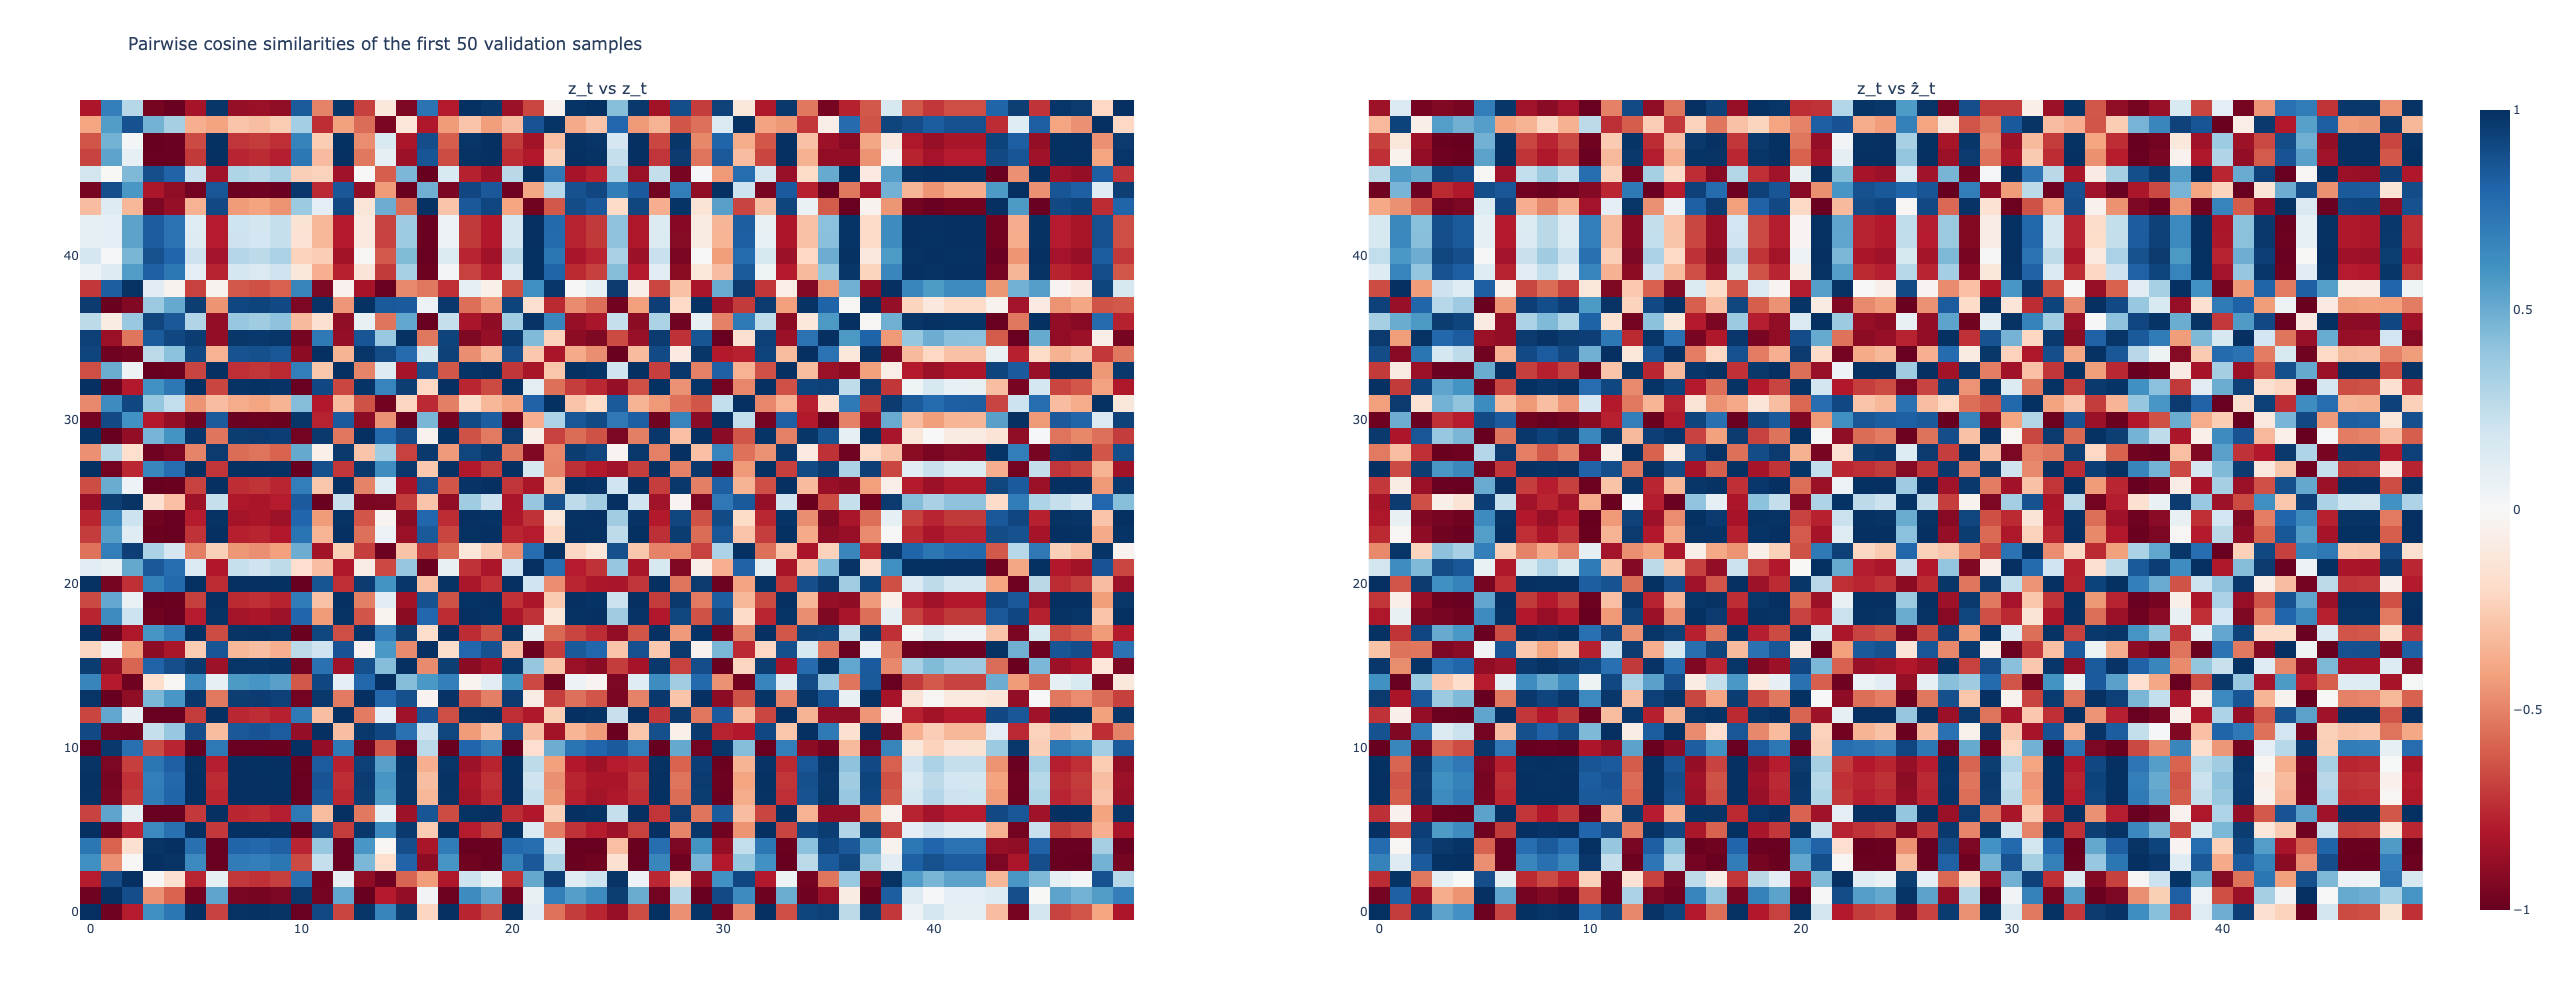

In [39]:
N = 50
zt = F.normalize(z_t, dim=-1)
zhat = F.normalize(z_hat_t, dim=-1)

sim_tt = (zt @ zt.T).numpy()    # text vs text
sim_that = (zt @ zhat.T).numpy()  # text vs predicted

fig = subplots.make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["z_t vs z_t", "z_t vs ẑ_t"],
)
fig.add_trace(
    go.Heatmap(z=sim_tt[:N, :N],   colorscale="RdBu", zmid=0, showscale=True),
    row=1,
    col=1,
)
fig.add_trace(
    go.Heatmap(z=sim_that[:N, :N], colorscale="RdBu", zmid=0, showscale=False),
    row=1,
    col=2,
)
fig.update_layout(
    title="Pairwise cosine similarities of the first 50 validation samples", width=2000, height=1000
)
fig.show()

Good news is that $\widehat{G}$ looks quite similar to $G$ and exhibits diagonal structure, giving us immediate signal that the model is learning some kind of alignment for paired samples. Additionally, the above is pretty clear evidence against representation collapse. Otherwise, we'd see uniformity. I would say that, in principle, the non-contrastive approach is sound. How well does this perform? Below we check the following:

- One-sided $t$ test of diagonal mean of $\widehat{G}$ against the off-diagonal mean
- Retrieval scores

In [35]:
N = len(z_t)
sim = (zt @ zhat.T).numpy()

diagonal = sim.diagonal()
off_diag = sim[~np.eye(N, dtype=bool)]

# Summary stats
print(f"Matched mean={diagonal.mean():.3f}  std={diagonal.std():.3f}")
print(f"Unmatched mean={off_diag.mean():.3f}  std={off_diag.std():.3f}")

# One-sided Welch t-test: is diagonal > off-diagonal?
t, p = stats.ttest_ind(diagonal, off_diag, alternative="greater", equal_var=False)
print(f"t={t:.2f}  p={p:.2e}")

# Retrieval metrics: for each image, rank its true caption among all captions
ranks = (sim > diagonal[:, None]).sum(axis=1) + 1  # rank of correct caption (1 = perfect)
print(f"Median rank: {np.median(ranks):.1f}")
print(f"R@1:  {(ranks <= 1).mean():.3f}")
print(f"R@5:  {(ranks <= 5).mean():.3f}")
print(f"R@10: {(ranks <= 10).mean():.3f}")

Matched    mean=0.763  std=0.471
Unmatched  mean=0.004  std=0.730
t=141.53  p=0.00e+00
Median rank: 698.0
R@1:  0.002
R@5:  0.008
R@10: 0.016


The $t$ test looks good. With statistical significance, we can say that the diagonal mean is greater than the off-diagonal mean. The recall scores and median rank are cause for worry, though. For clarity, "median rank" refers to the median rank of the true text embedding when ordering them by similarity to the estimated embedding. We'd like both the recall scores and the median rank to be as high as possible.

So, the $t$ test implies strong alignment, but the retrieval scores imply that the model can't quite discriminate well. We need more training samples, and we need higher diversity in captions.